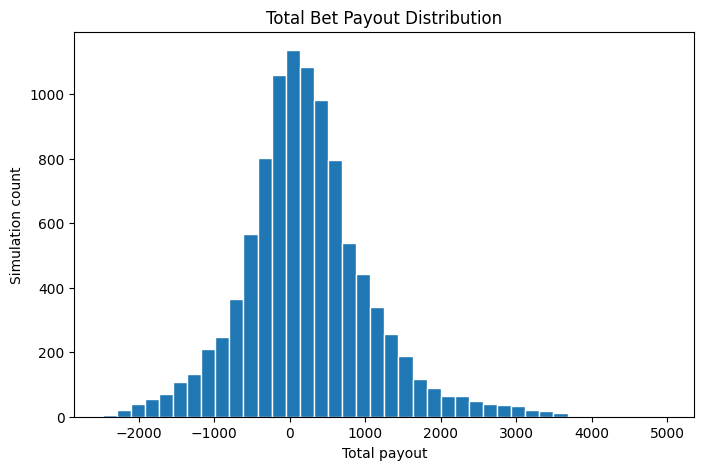

,expected_payout,standard_deviation,min,max
bet,,,,
Ecuador C20 36 @ 6.75,-40.4460,525.698618,-243.0,3177.0
France P20 50 @ 1.5,-29.1250,116.358216,-75.0,675.0
Switzerland F 5 @ 23,-12.7525,94.408084,-115.0,460.0
Uruguay C20 5 @ 7,-1.3450,85.629819,-35.0,440.0
Uruguay C80 2 @ 0.5,0.0850,7.117076,-1.0,69.0
Ghana P20 1 @ 12,3.7640,5.703622,-12.0,8.0
Canada F 10 @ 18,8.8550,151.898120,-180.0,970.0
Netherlands C20 -10 @ 13,21.6600,210.258042,-820.0,130.0
France F -5 @ 50,31.1950,151.371635,-350.0,225.0


In [15]:
import json
import re
from difflib import get_close_matches
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.image as mpimg
import matplotlib.image as mpimg
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SIM_META_PATH = Path("model_output/simulation_runs_meta.json")
SIM_RUNS_PATH = Path("model_output/simulation_runs.jsonl")
BETS_PATH = Path("bets.txt")

PROGRESSION_STAGE_VALUES = {
    "Round of 32": 5.0,
    "Round of 16": 10.0,
    "Quarterfinal": 20.0,
    "Semifinal": 40.0,
    "Final": 60.0,
    "Champion": 80.0,
}
WIN_VALUE_PER_90 = 5.0

with SIM_META_PATH.open("r") as f:
    meta = json.load(f)

with SIM_RUNS_PATH.open("r") as f:
    simulation_rows = [json.loads(line) for line in f if line.strip()]

teams = meta["teams"]
stages = meta["stages"]
team_to_id = {team: idx for idx, team in enumerate(teams)}


def canonicalize_team_name(raw_team: str):
    team = raw_team.strip()
    if team in team_to_id:
        return team, None
    matches = get_close_matches(team, teams, n=1, cutoff=0.7)
    if not matches:
        raise ValueError(f"Unknown team in bets.txt: {raw_team!r}")
    return matches[0], f"Mapped team {raw_team!r} to {matches[0]!r}"


def parse_bet_line(line: str, line_no: int) -> dict:
    cleaned = line.strip()
    if not cleaned:
        raise ValueError("Empty bet line")
    if " & " in cleaned:
        cleaned = cleaned.replace(" & ", " @ ")
        separator_note = f"Replaced '&' with '@' on line {line_no}"
    else:
        separator_note = None

    match = re.fullmatch(
        r"(?P<team>.+?)\s+(?P<contract>F|C(?P<call_strike>\d+)|P(?P<put_strike>\d+))\s+(?P<lots>[+-]?\d+(?:\.\d+)?)\s*@\s*(?P<price>[+-]?\d+(?:\.\d+)?)",
        cleaned,
    )
    if not match:
        raise ValueError(f"Could not parse bet line {line_no}: {line!r}")

    team, team_note = canonicalize_team_name(match.group("team"))
    contract = match.group("contract")
    lots = float(match.group("lots"))
    price = float(match.group("price"))

    if contract == "F":
        instrument_type = "future"
        strike = None
        instrument_key = (team, instrument_type, strike)
    elif contract.startswith("C"):
        instrument_type = "call"
        strike = int(match.group("call_strike"))
        instrument_key = (team, instrument_type, strike)
    else:
        instrument_type = "put"
        strike = int(match.group("put_strike"))
        instrument_key = (team, instrument_type, strike)

    notes = [note for note in [separator_note, team_note] if note]
    return {
        "line_no": line_no,
        "raw_line": line,
        "team": team,
        "instrument_type": instrument_type,
        "strike": strike,
        "lots": lots,
        "price": price,
        "instrument_key": instrument_key,
        "notes": notes,
    }


def compute_team_total_values(sim_records):
    team_count = len(teams)
    total_values = np.zeros((len(sim_records), team_count), dtype=float)
    for sim_idx, record in enumerate(sim_records):
        run_progression_value = np.zeros(team_count, dtype=float)
        run_win_value = np.zeros(team_count, dtype=float)
        for match in record.get("m", []):
            stage_name = stages[match[0]]
            home_id = int(match[2])
            away_id = int(match[3])
            home_score = int(match[4])
            away_score = int(match[5])
            went_penalties = bool(match[7])
            penalty_winner_id = int(match[8])
            home_score_90 = int(match[9])
            away_score_90 = int(match[10])

            if stage_name == "Group":
                if home_score > away_score:
                    run_win_value[home_id] += WIN_VALUE_PER_90
                elif away_score > home_score:
                    run_win_value[away_id] += WIN_VALUE_PER_90
                continue

            if home_score_90 > away_score_90:
                run_win_value[home_id] += WIN_VALUE_PER_90
            elif away_score_90 > home_score_90:
                run_win_value[away_id] += WIN_VALUE_PER_90

            if went_penalties and penalty_winner_id != -1:
                winner = penalty_winner_id
            elif home_score > away_score:
                winner = home_id
            else:
                winner = away_id
            loser = away_id if winner == home_id else home_id

            if stage_name in ("Round of 32", "Round of 16", "Quarterfinal", "Semifinal"):
                run_progression_value[loser] = PROGRESSION_STAGE_VALUES[stage_name]
            elif stage_name == "Final":
                run_progression_value[loser] = PROGRESSION_STAGE_VALUES["Final"]
                run_progression_value[winner] = PROGRESSION_STAGE_VALUES["Champion"]

        total_values[sim_idx] = run_progression_value + run_win_value
    return total_values


parsed_bets = []
parse_notes = []
for line_no, raw_line in enumerate(BETS_PATH.read_text().splitlines(), start=1):
    stripped = raw_line.strip()
    if not stripped:
        continue
    bet = parse_bet_line(stripped, line_no)
    parsed_bets.append(bet)
    parse_notes.extend(bet["notes"])

bets_raw_df = pd.DataFrame(parsed_bets)

aggregated_rows = []
for instrument_key, sub in bets_raw_df.groupby("instrument_key", sort=True):
    team, instrument_type, strike = instrument_key
    net_lots = sub["lots"].sum()
    total_cost = (sub["lots"] * sub["price"]).sum()
    average_price = total_cost / net_lots if abs(net_lots) > 1e-12 else np.nan
    if instrument_type == "future":
        label = f"{team} F {net_lots:g} @ {average_price:g}"
    elif instrument_type == "call":
        label = f"{team} C{strike} {net_lots:g} @ {average_price:g}"
    else:
        label = f"{team} P{strike} {net_lots:g} @ {average_price:g}"
    aggregated_rows.append(
        {
            "bet": label,
            "team": team,
            "instrument_type": instrument_type,
            "strike": strike,
            "net_lots": net_lots,
            "total_cost": total_cost,
        }
    )

bets_aggregated_df = (
    pd.DataFrame(aggregated_rows)
    .sort_values(["team", "instrument_type", "strike"], na_position="first")
    .reset_index(drop=True)
)

team_total_values = compute_team_total_values(simulation_rows)

bet_payoff_series = {}
for row in bets_aggregated_df.itertuples(index=False):
    team_id = team_to_id[row.team]
    intrinsic = team_total_values[:, team_id]
    if row.instrument_type == "call":
        intrinsic = np.maximum(intrinsic - row.strike, 0.0)
    elif row.instrument_type == "put":
        intrinsic = np.maximum(row.strike - intrinsic, 0.0)
    payout = row.net_lots * intrinsic - row.total_cost
    bet_payoff_series[row.bet] = payout

bet_payoffs_df = pd.DataFrame(bet_payoff_series)
if bet_payoffs_df.empty:
    raise ValueError("No non-empty bets parsed from bets.txt")

total_payoff_series = bet_payoffs_df.sum(axis=1)

summary_rows = []
for bet_name in bet_payoffs_df.columns:
    payouts = bet_payoffs_df[bet_name].to_numpy()
    summary_rows.append(
        {
            "bet": bet_name,
            "expected_payout": float(payouts.mean()),
            "standard_deviation": float(payouts.std(ddof=0)),
            "min": float(payouts.min()),
            "max": float(payouts.max()),
        }
    )

summary_rows.append(
    {
        "bet": "Total",
        "expected_payout": float(total_payoff_series.mean()),
        "standard_deviation": float(total_payoff_series.std(ddof=0)),
        "min": float(total_payoff_series.min()),
        "max": float(total_payoff_series.max()),
    }
)

bets_summary_df = pd.DataFrame(summary_rows).set_index("bet")
parse_notes_series = (
    pd.Series(parse_notes, name="parse_note")
    if parse_notes
    else pd.Series(dtype=object, name="parse_note")
)

ax = total_payoff_series.plot.hist(bins=40, figsize=(8, 5), edgecolor="white")
ax.set_title("Total Bet Payout Distribution")
ax.set_xlabel("Total payout")
ax.set_ylabel("Simulation count")
plt.show()

bets_summary_df.sort_values("expected_payout")

In [16]:
bets_summary_df.sort_values("expected_payout")

,expected_payout,standard_deviation,min,max
bet,,,,
Ecuador C20 36 @ 6.75,-40.4460,525.698618,-243.0,3177.0
France P20 50 @ 1.5,-29.1250,116.358216,-75.0,675.0
Switzerland F 5 @ 23,-12.7525,94.408084,-115.0,460.0
Uruguay C20 5 @ 7,-1.3450,85.629819,-35.0,440.0
Uruguay C80 2 @ 0.5,0.0850,7.117076,-1.0,69.0
Ghana P20 1 @ 12,3.7640,5.703622,-12.0,8.0
Canada F 10 @ 18,8.8550,151.898120,-180.0,970.0
Netherlands C20 -10 @ 13,21.6600,210.258042,-820.0,130.0
France F -5 @ 50,31.1950,151.371635,-350.0,225.0


In [14]:
from IPython.display import Markdown, display

def simulation_matches_df(sim_index: int) -> pd.DataFrame:
    record = simulation_rows[sim_index]
    rows = []
    for match in record["m"]:
        stage_name = stages[match[0]]
        home_team = teams[int(match[2])]
        away_team = teams[int(match[3])]
        home_score = int(match[4])
        away_score = int(match[5])
        rows.append(
            {
                "stage": stage_name,
                "home_team": home_team,
                "away_team": away_team,
                "score": f"{home_score}-{away_score}",
            }
        )
    return pd.DataFrame(rows)


def describe_simulation(sim_index: int, label: str):
    total_payoff = float(total_payoff_series.iloc[sim_index])
    bet_payouts = bet_payoffs_df.iloc[sim_index].sort_values(ascending=False)
    worst_bets = bet_payouts.sort_values().head(5).rename("payout")
    best_bets = bet_payouts.head(5).rename("payout")
    teams_in_book = sorted(bets_aggregated_df["team"].unique())
    team_values = (
        pd.Series({team: float(team_total_values[sim_index, team_to_id[team]]) for team in teams_in_book})
        .sort_values(ascending=False)
        .rename("team_value")
    )
    matches_df = simulation_matches_df(sim_index)
    final_match = matches_df.loc[matches_df["stage"] == "Final"].tail(1)

    display(Markdown(f"## {label} Simulation"))
    display(pd.DataFrame({"sim_index": [sim_index], "total_payoff": [total_payoff]}))
    if not final_match.empty:
        display(Markdown("**Final**"))
        display(final_match.reset_index(drop=True))
    display(Markdown("**Top 5 winning bets**"))
    display(best_bets.to_frame())
    display(Markdown("**Top 5 losing bets**"))
    display(worst_bets.to_frame())
    display(Markdown("**Booked teams by simulated team value**"))
    display(team_values.to_frame())
    display(Markdown("**Knockout bracket**"))
    display(matches_df.loc[matches_df["stage"] != "Group"].reset_index(drop=True))


best_sim_index = int(total_payoff_series.idxmax())
worst_sim_index = int(total_payoff_series.idxmin())

describe_simulation(best_sim_index, "Best")
describe_simulation(worst_sim_index, "Worst")

## Best Simulation

,sim_index,total_payoff
0,3753,4409.0


**Final**

,stage,home_team,away_team,score
0,Final,Ecuador,Brazil,1-0


**Top 5 winning bets**

...

,payout
Netherlands F -10 @ 30,-800.0
Netherlands C20 -10 @ 13,-770.0
Ecuador C20 36 @ 6.75,-243.0
France F -5 @ 50,-200.0
Canada F 10 @ 18,-180.0


**Booked teams by simulated team value**

,team_value
Netherlands,110.0
France,90.0
Argentina,25.0
Colombia,25.0
Ecuador,15.0
Switzerland,15.0
Uruguay,10.0
Ghana,5.0
Canada,0.0


**Knockout bracket**

,stage,home_team,away_team,score
0,Round of 32,South Korea,Qatar,1-1
1,Round of 32,Ivory Coast,Morocco,2-1
2,Round of 32,Sweden,Scotland,5-2
3,Round of 32,Brazil,Netherlands,0-1
4,Round of 32,France,Turkey,3-0
5,Round of 32,Germany,Senegal,2-3
6,Round of 32,Mexico,Saudi Arabia,1-2
7,Round of 32,England,DR Congo,1-0
8,Round of 32,USA,Ecuador,0-1
9,Round of 32,Iran,South Africa,2-0


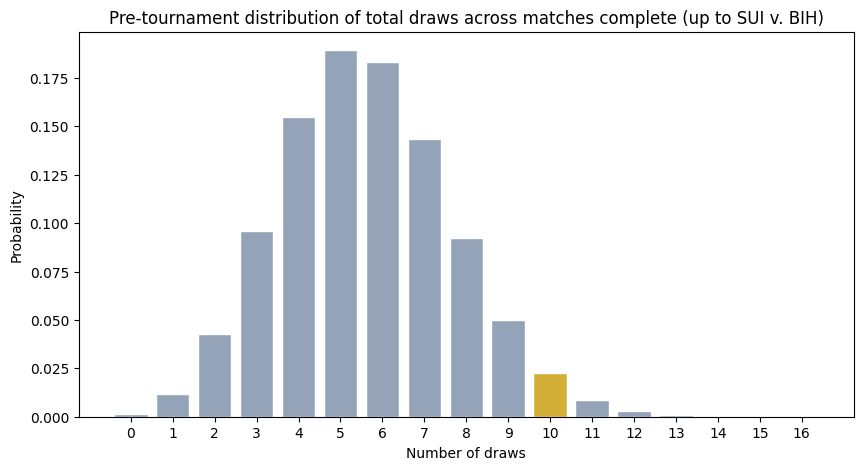

,match_id,date,match,is_draw,draw_probability,probability_source
0,1,2026-06-11,Mexico vs South Africa,False,0.223118,pre-tournament
1,2,2026-06-11,South Korea vs Czechia,False,0.293584,pre-tournament
2,3,2026-06-12,Canada vs Bosnia and Herzegovina,True,0.204972,pre-tournament
3,4,2026-06-12,USA vs Paraguay,False,0.313473,pre-tournament
4,5,2026-06-13,Haiti vs Scotland,False,0.206169,pre-tournament
5,6,2026-06-13,Australia vs Turkey,False,0.278237,pre-tournament
6,7,2026-06-13,Brazil vs Morocco,True,0.305012,pre-tournament
7,8,2026-06-13,Qatar vs Switzerland,True,0.093633,pre-tournament
8,9,2026-06-14,Ivory Coast vs Ecuador,False,0.252453,pre-tournament
9,10,2026-06-14,Germany vs Curacao,False,0.039172,pre-tournament


In [23]:
import json
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULTS_PATH = Path("match_results/results_wc2026.csv")
CURRENT_PROB_PATH = Path("web/public/model_output/win_probabilities.json")
PRETOURNAMENT_PROB_PATH = Path("web/public/model_output_pretournament/win_probabilities.json")
CAPE_VERDE_FLAG_PATH = Path("web/public/flags/Cape_Verde.png")

HOST_TEAM_COUNTRIES = {
    "USA": "USA",
    "United States": "USA",
    "Canada": "Canada",
    "Mexico": "Mexico",
}
HOST_TEAMS = {"USA", "Canada", "Mexico"}

with CURRENT_PROB_PATH.open("r") as f:
    current_probabilities = json.load(f)

with PRETOURNAMENT_PROB_PATH.open("r") as f:
    pretournament_probabilities = json.load(f)

results_wc2026 = pd.read_csv(RESULTS_PATH, keep_default_na=True, na_values=["NA"])
completed_results = results_wc2026.loc[
    results_wc2026["home_score"].notna() & results_wc2026["away_score"].notna()
].copy()


def normalize_country(value):
    return "" if pd.isna(value) else str(value).strip().lower()


def resolve_match_neutrality(home_team, away_team, country, neutral_override):
    if pd.notna(neutral_override):
        neutral = bool(neutral_override)
        return {"neutral": neutral, "advantage": None if neutral else "home"}
    neutral = True
    advantage = None
    if pd.notna(country):
        match_country = normalize_country(country)
        home_country = normalize_country(HOST_TEAM_COUNTRIES.get(home_team, ""))
        away_country = normalize_country(HOST_TEAM_COUNTRIES.get(away_team, ""))
        home_advantage = bool(home_country and match_country and home_country == match_country)
        away_advantage = bool(away_country and match_country and away_country == match_country)
        if home_advantage and away_advantage:
            neutral = True
        elif home_advantage or away_advantage:
            neutral = False
            advantage = "home" if home_advantage else "away"
    else:
        home_is_host = home_team in HOST_TEAMS
        away_is_host = away_team in HOST_TEAMS
        if home_is_host != away_is_host:
            neutral = False
            advantage = "home" if home_is_host else "away"
    return {"neutral": neutral, "advantage": advantage}


def is_compact(probabilities):
    return isinstance(probabilities, dict) and "teams" in probabilities and "entries" in probabilities


def build_compact_lookup(probabilities):
    teams = probabilities["teams"]
    team_index = {team: idx for idx, team in enumerate(teams)}
    lookup = {}
    for entry in probabilities["entries"]:
        if not isinstance(entry, list) or len(entry) < 11:
            continue
        friendly_flag = entry[3] if len(entry) > 11 else 0
        key = (int(entry[0]), int(entry[1]), int(entry[2]), int(friendly_flag))
        lookup[key] = entry
    return team_index, lookup


pretournament_team_index, pretournament_lookup = build_compact_lookup(pretournament_probabilities)
current_team_index, current_lookup = build_compact_lookup(current_probabilities)


def parse_compact_entry(entry):
    shift = 0 if len(entry) > 11 else -1
    return {
        "p_home": entry[7 + shift],
        "p_draw": entry[8 + shift],
        "p_away": entry[9 + shift],
    }


def resolve_compact_entry(team_index, lookup, home_team, away_team, neutral):
    home_id = team_index.get(home_team)
    away_id = team_index.get(away_team)
    if home_id is None or away_id is None:
        return None
    return lookup.get((home_id, away_id, 1 if neutral else 0, 0))


def resolve_draw_probability(probabilities, team_index, lookup, row):
    neutrality = resolve_match_neutrality(
        row.home_team,
        row.away_team,
        row.country,
        row.neutral,
    )
    if neutrality["neutral"]:
        entry = resolve_compact_entry(team_index, lookup, row.home_team, row.away_team, True)
    elif neutrality["advantage"] == "home":
        entry = resolve_compact_entry(team_index, lookup, row.home_team, row.away_team, False)
    elif neutrality["advantage"] == "away":
        entry = resolve_compact_entry(team_index, lookup, row.away_team, row.home_team, False)
    else:
        entry = None
    if entry is None:
        return None
    parsed = parse_compact_entry(entry)
    return float(parsed["p_draw"])


draw_probability_rows = []
for row in completed_results.itertuples(index=False):
    pretournament_draw_probability = resolve_draw_probability(
        pretournament_probabilities,
        pretournament_team_index,
        pretournament_lookup,
        row,
    )
    current_draw_probability = resolve_draw_probability(
        current_probabilities,
        current_team_index,
        current_lookup,
        row,
    )
    selected_draw_probability = (
        pretournament_draw_probability
        if pretournament_draw_probability is not None
        else current_draw_probability
    )
    if selected_draw_probability is None:
        continue
    draw_probability_rows.append(
        {
            "match_id": int(row.match_id),
            "date": row.date,
            "match": f"{row.home_team} vs {row.away_team}",
            "is_draw": bool(int(row.home_score) == int(row.away_score)),
            "draw_probability": selected_draw_probability,
            "probability_source": "pre-tournament" if pretournament_draw_probability is not None else "current",
        }
    )

completed_draw_probabilities_df = pd.DataFrame(draw_probability_rows).sort_values(["date", "match_id"]).reset_index(drop=True)
draw_probabilities = completed_draw_probabilities_df["draw_probability"].to_numpy(dtype=float)
observed_draws = int(completed_draw_probabilities_df["is_draw"].sum())

draw_count_distribution = np.array([1.0])
for p_draw in draw_probabilities:
    draw_count_distribution = np.convolve(draw_count_distribution, np.array([1 - p_draw, p_draw]))

draw_count_distribution_series = pd.Series(
    draw_count_distribution,
    index=pd.Index(range(len(draw_count_distribution)), name="draw_count"),
    name="probability",
)

plot_distribution_series = draw_count_distribution_series.loc[
    (draw_count_distribution_series >= 1e-6)
    | (draw_count_distribution_series.index == observed_draws)
]
bar_colors = ["#94a3b8"] * len(plot_distribution_series)
if observed_draws in plot_distribution_series.index:
    bar_colors[list(plot_distribution_series.index).index(observed_draws)] = "#d4af37"

fig, ax = plt.subplots(figsize=(10, 5))
cape_verde_flag = mpimg.imread(CAPE_VERDE_FLAG_PATH)
# ax.imshow(
#     cape_verde_flag,
#     extent=(
#         plot_distribution_series.index.min() - 0.5,
#         plot_distribution_series.index.max() + 0.5,
#         0,
#         max(plot_distribution_series.max() * 1.05, 1e-9),
#     ),
#     aspect="auto",
#     alpha=0.09,
#     zorder=0,
# )
ax.bar(plot_distribution_series.index, plot_distribution_series.values, color=bar_colors, edgecolor="white")
ax.set_title("Pre-tournament distribution of total draws across matches complete (up to SUI v. BIH)")
ax.set_xlabel("Number of draws")
ax.set_ylabel("Probability")
ax.set_xticks(plot_distribution_series.index)
plt.show()

completed_draw_probabilities_df

In [24]:
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd

SIM_META_PATH = Path("model_output/simulation_runs_meta.json")
SIM_RUNS_PATH = Path("model_output/simulation_runs.jsonl")

with SIM_META_PATH.open("r") as f:
    sim_meta = json.load(f)

with SIM_RUNS_PATH.open("r") as f:
    simulation_rows = [json.loads(line) for line in f if line.strip()]

teams = sim_meta["teams"]
stages = sim_meta["stages"]
round_of_32_stage_id = stages.index("Round of 32")

combo_counts = defaultdict(int)
combo_finish_third_counts = defaultdict(int)
combo_finish_third_and_r32_counts = defaultdict(int)

for sim in simulation_rows:
    group_rankings = sim["gr"]
    group_tables = sim["gt"]
    r32_teams = set()
    for match in sim["m"]:
        if int(match[0]) != round_of_32_stage_id:
            continue
        r32_teams.add(int(match[2]))
        r32_teams.add(int(match[3]))

    for ranking, table in zip(group_rankings, group_tables):
        team_to_rank = {int(team_id): rank for rank, team_id in enumerate(ranking, start=1)}
        for row in table:
            team_id = int(row[0])
            points = int(row[1])
            gd = int(row[2])
            gf = int(row[3])
            combo = (points, gd, gf)
            combo_counts[combo] += 1
            rank = team_to_rank[team_id]
            if rank == 3:
                combo_finish_third_counts[combo] += 1
                if team_id in r32_teams:
                    combo_finish_third_and_r32_counts[combo] += 1

records = []
for combo in sorted(combo_counts):
    total_count = combo_counts[combo]
    third_count = combo_finish_third_counts[combo]
    third_and_r32_count = combo_finish_third_and_r32_counts[combo]
    p_finish_third = third_count / total_count if total_count else np.nan
    p_r32_given_third = third_and_r32_count / third_count if third_count else np.nan
    records.append(
        {
            "points": combo[0],
            "gd": combo[1],
            "gf": combo[2],
            "count": total_count,
            "third_count": third_count,
            "third_and_r32_count": third_and_r32_count,
            "p_finish_3rd_given_combo": p_finish_third,
            "p_reach_r32_given_3rd_and_combo": p_r32_given_third,
        }
    )

third_place_combo_df = (
    pd.DataFrame(records)
    .sort_values(["points", "gd", "gf"], ascending=[False, False, False])
    .reset_index(drop=True)
)

third_place_combo_df

,points,gd,gf,count,third_count,third_and_r32_count,p_finish_3rd_given_combo,p_reach_r32_given_3rd_and_combo
0,9,22,25,1,0,0,0.0,NaN
1,9,21,21,1,0,0,0.0,NaN
2,9,19,25,1,0,0,0.0,NaN
3,9,19,22,1,0,0,0.0,NaN
4,9,19,21,1,0,0,0.0,NaN
...,...,...,...,...,...,...,...,...
1079,0,-19,1,10,0,0,0.0,NaN
1080,0,-20,2,3,0,0,0.0,NaN
1081,0,-20,1,3,0,0,0.0,NaN
1082,0,-22,1,1,0,0,0.0,NaN


In [35]:
## Preamble ##

%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import gamma

from src.model import Model
from src.model_elo import EloModel

def dr(df):
    with pd.option_context('display.max_rows', None):
        display(df)
        
def dc(df):
    with pd.option_context('display.max_columns', None):
        display(df)
        
def drc(df):
    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        display(df)
dcr = drc

In [41]:
dcr(
    third_place_combo_df.groupby(["points", "gd"]).apply(lambda G: G.third_and_r32_count.sum() / G.third_count.sum()).reset_index()
    .rename(columns={0: "p_reach_r32_given_3rd_and_points_gd"})
    .query("p_reach_r32_given_3rd_and_points_gd.notna()")
    .sort_values(["points", "gd"], ascending=False)
    .set_index(["points", "gd"])
    .unstack().T
)

/var/folders/y9/7mrfwwc97kg93k2qmfccslvm0000gn/T/ipykernel_50857/2623848277.py:2: RuntimeWarning: invalid value encountered in scalar divide
  third_place_combo_df.groupby(["points", "gd"]).apply(lambda G: G.third_and_r32_count.sum() / G.third_count.sum()).reset_index()
/var/folders/y9/7mrfwwc97kg93k2qmfccslvm0000gn/T/ipykernel_50857/2623848277.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  third_place_combo_df.groupby(["points", "gd"]).apply(lambda G: G.third_and_r32_count.sum() / G.third_count.sum()).reset_index()


points                                     1         2         3         4  \
                                    gd                                       
p_reach_r32_given_3rd_and_points_gd -17  NaN       NaN  0.000000       NaN   
                                    -14  NaN       NaN  1.000000       NaN   
                                    -13  NaN       NaN  0.000000       NaN   
                                    -12  NaN       NaN  0.454545       NaN   
                                    -11  NaN       NaN  0.342105  1.000000   
                                    -10  NaN  0.000000  0.260870  1.000000   
                                    -9   NaN  0.000000  0.274725  1.000000   
                                    -8   0.0  0.000000  0.272727  0.923077   
                                    -7   0.0  0.000000  0.264384  0.939394   
                                    -6   0.0  0.000000  0.303400  0.970588   
                                    -5   0.0  0.000000  0.364427  0.994334   
                                    -4   0.0  0.002105  0.426042  0.987805   
                                    -3   0.0  0.006260  0.571959  0.978136   
                                    -2   0.0  0.029799  0.737691  0.992299   
                                    -1   NaN  0.115727  0.859823  0.998622   
                                     0   NaN       NaN  0.938806  1.000000   
                                     1   NaN       NaN  0.965770  1.000000   
                                     2   NaN       NaN  0.985366  1.000000   
                                     3   NaN       NaN  0.983914  1.000000   
                                     4   NaN       NaN  0.984556  1.000000   
                                     5   NaN       NaN  1.000000  1.000000   
                                     6   NaN       NaN  1.000000  1.000000   
                                     7   NaN       NaN  1.000000  1.000000   
                                     8   NaN       NaN  1.000000  1.000000   
                                     9   NaN       NaN  1.000000  1.000000   
                                     10  NaN       NaN       NaN       NaN   

points                                     5    6  
                                    gd             
p_reach_r32_given_3rd_and_points_gd -17  NaN  NaN  
                                    -14  NaN  NaN  
                                    -13  NaN  NaN  
                                    -12  NaN  NaN  
                                    -11  NaN  NaN  
                                    -10  NaN  NaN  
                                    -9   NaN  NaN  
                                    -8   NaN  1.0  
                                    -7   NaN  1.0  
                                    -6   NaN  1.0  
                                    -5   NaN  1.0  
                                    -4   NaN  1.0  
                                    -3   NaN  1.0  
                                    -2   NaN  1.0  
                                    -1   NaN  1.0  
                                     0   NaN  1.0  
                                     1   1.0  1.0  
                                     2   1.0  1.0  
                                     3   1.0  1.0  
                                     4   1.0  1.0  
                                     5   1.0  1.0  
                                     6   1.0  1.0  
                                     7   1.0  1.0  
                                     8   1.0  1.0  
                                     9   1.0  1.0  
                                     10  1.0  NaN

In [1]:
import pandas as pd

df = pd.read_csv("model_output/ratings_history_yearly.csv")

In [8]:
df

,date,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Anguilla,Antigua and Barbuda,Argentina,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,Wales,Yemen,Yugoslavia,Zambia,Zimbabwe
0,1872-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1873-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1874-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1875-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1876-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,85.869389,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,2022-01-01,22.362811,60.493831,79.494060,1.884506,25.994651,52.913022,4.510773,23.599641,97.254742,...,89.926541,62.150595,19.495424,76.140658,45.165748,78.933035,23.802888,NaN,55.823225,49.990674
151,2023-01-01,19.721285,67.240701,77.065295,1.038267,27.478390,51.400066,4.247123,16.728519,97.645158,...,93.037063,66.844938,18.021611,81.341710,44.765018,77.220383,25.681720,NaN,58.266576,52.151979
152,2024-01-01,22.084379,68.674304,76.152966,1.097059,26.119915,58.604779,4.097357,13.973183,97.622853,...,92.747274,67.102738,14.027282,80.570510,40.243236,78.075833,27.272137,NaN,56.912408,52.020020
153,2025-01-01,20.571926,69.633956,78.155024,1.095065,28.429439,56.068023,4.099092,14.132765,97.972845,...,91.150359,70.495844,15.553255,78.591074,37.322483,78.305203,32.278006,NaN,53.792276,50.503164


In [2]:
df["mu_sum"] = df["mu_attack"] + df["mu_defense"]
df["tilt"] = df["mu_attack"] - df["mu_defense"]

<Axes: ylabel='Frequency'>

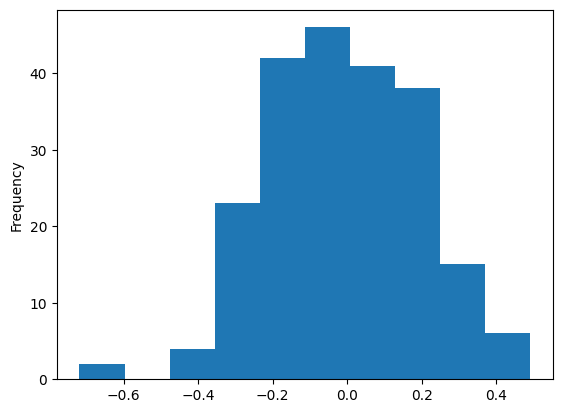

In [6]:
df.tilt.plot.hist()

In [19]:
df.sort_values("tilt", ascending=False).head(20)

,team,mu_attack,mu_defense,sigma_attack,sigma_defense,sigma_ad,mu_global,quality,quality_low,mu_attack_low,mu_defense_low,year,rating_attack,rating_defense,rating,mu_sum,tilt
187,St Vincent and the Grenadines,-1.398502,-1.890905,0.020310,0.018437,0.008615,0.265569,-3.289407,-3.762601,-1.683530,-2.162470,2026.0,31.989342,16.858501,23.533678,-3.289407,0.492403
22,Bermuda,-1.423362,-1.898133,0.020603,0.017695,0.007892,0.265569,-3.321495,-3.786603,-1.710436,-2.164177,2026.0,31.053398,16.688028,23.045508,-3.321495,0.474770
77,Germany,0.208238,-0.226568,0.014030,0.018789,0.008157,0.265569,-0.018330,-0.461655,-0.028656,-0.500717,2026.0,97.201333,85.702070,92.738463,-0.018330,0.434807
98,Israel,-0.361825,-0.784555,0.018194,0.016490,0.008487,0.265569,-1.146380,-1.600952,-0.631593,-1.041385,2026.0,80.193660,59.864269,70.381358,-1.146380,0.422729
147,Northern Mariana Islands,-2.961141,-3.352407,0.065210,0.030410,0.017955,0.265569,-6.313548,-7.038893,-3.471867,-3.701177,2026.0,3.098856,1.544665,2.197246,-6.313548,0.391266
10,Aruba,-1.683626,-2.059878,0.026655,0.021713,0.010288,0.265569,-3.743504,-4.268646,-2.010152,-2.354587,2026.0,22.362511,13.224527,17.317005,-3.743504,0.376252
87,Guyana,-1.177801,-1.538767,0.019576,0.020820,0.009284,0.265569,-2.716568,-3.202219,-1.457627,-1.827350,2026.0,41.066706,26.949556,33.541850,-2.716568,0.360965
14,Bahamas,-2.330663,-2.685133,0.031942,0.019298,0.009387,0.265569,-5.015796,-5.545003,-2.688112,-2.962967,2026.0,8.775050,4.953895,6.623703,-5.015796,0.354470
175,Sint Maarten,-1.869083,-2.218117,0.037602,0.023078,0.010326,0.265569,-4.087200,-4.657577,-2.256908,-2.521947,2026.0,17.381695,10.437279,13.543701,-4.087200,0.349035
109,Laos,-2.086331,-2.431170,0.027354,0.017553,0.010536,0.265569,-4.517500,-5.031227,-2.417109,-2.696148,2026.0,12.719231,7.490166,9.808328,-4.517500,0.344839
